## Data Manipulation Tasks

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


### 1. Importing CSV using Pandas

In [ ]:
csv_file_path = '/content/social_media_engagement_5000.csv'
try:
    df = pd.read_csv(csv_file_path)
    print(f"CSV '{csv_file_path}' loaded successfully.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: '{csv_file_path}' not found. Please ensure the file exists at the specified path.")


CSV '/content/social_media_engagement_5000.csv' loaded successfully.


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


### 2. Checking/Converting Data Types

In [ ]:
print("Original data types:")
display(df.info())

Original data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         485

None

### 3. Converting Date Columns to Datetime

In [ ]:
date_columns = ['posted_at']

for col in date_columns:
    if col in df.columns:
        if df[col].dtype != 'datetime64[ns]':
                df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)
                print(f"Converted '{col}' to datetime. Number of NaT values: {df[col].isnull().sum()}")
        else:
                print(f"Column '{col}' is already of datetime type.")
    else:
        print(f"Column '{col}' not found in DataFrame. Skipping date conversion for this column.")

print("\nData types after date conversion:")
display(df.info())

Converted 'posted_at' to datetime. Number of NaT values: 0

Data types after date conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               4850 non-null   float64       
 2   gender            4850 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             4850 non-null   float64       
 8   comments          4850 non-null   float64       
 9   shares            4850 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   date

None

### 4. Using NumPy arrays for basic array operations

In [ ]:
numeric_column = 'likes'

if numeric_column in df.columns and pd.api.types.is_numeric_dtype(df[numeric_column]):
    numpy_array = df[numeric_column].dropna().values
    print(f"NumPy array from '{numeric_column}' column:")
    print(numpy_array)

    # Basic array operations
    print(f"Sum of array elements: {np.sum(numpy_array)}")
    print(f"Mean of array elements: {np.mean(numpy_array)}")
    print(f"Max of array elements: {np.max(numpy_array)}")

    # Example of creating a new NumPy array and performing operations
    arr1 = np.array([1, 2, 3, 4, 5])
    arr2 = np.array([6, 7, 8, 9, 10])
    print("\nArray 1:", arr1)
    print("Array 2:", arr2)
    print("Element-wise addition (arr1 + arr2):", arr1 + arr2)
    print("Element-wise multiplication (arr1 * arr2):", arr1 * arr2)
else:
    print(f"Column '{numeric_column}' not found or is not numeric in DataFrame. Cannot demonstrate NumPy operations on it.")
    arr = np.arange(10)
    print("Generated a sample NumPy array:", arr)
    print("Square of each element:", arr**2)

NumPy array from 'likes' column:
[ 7011. 11750.  4862. ... 13487. 16894. 14830.]
Sum of array elements: 49019162.0
Mean of array elements: 10107.043711340206
Max of array elements: 19998.0

Array 1: [1 2 3 4 5]
Array 2: [ 6  7  8  9 10]
Element-wise addition (arr1 + arr2): [ 7  9 11 13 15]
Element-wise multiplication (arr1 * arr2): [ 6 14 24 36 50]


## Data Cleaning

### Cleaning Missing Data



In [ ]:
print("Missing values before cleaning:")
display(df.isnull().sum())

Missing values before cleaning:


,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


Handling the missing values using different strategies:

In [ ]:
if 'age' in df.columns:
    median_age = df['age'].median()
    df['age'] = df['age'].fillna(median_age)
    print(f"Filled missing 'age' values with median: {median_age}")

for col in ['likes', 'comments', 'shares']:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled missing '{col}' values with median: {median_val}")

if 'gender' in df.columns:
    mode_gender = df['gender'].mode()[0]
    df['gender'] = df['gender'].fillna(mode_gender)
    print(f"Filled missing 'gender' values with mode: {mode_gender}")

if 'sentiment' in df.columns:
    mode_sentiment = df['sentiment'].mode()[0]
    df['sentiment'] = df['sentiment'].fillna(mode_sentiment)
    print(f"Filled missing 'sentiment' values with mode: {mode_sentiment}")

print("\nMissing values after cleaning (should be 0 for 'age', 'gender', 'likes', 'comments', 'shares', 'sentiment'):")
display(df.isnull().sum())

Filled missing 'age' values with median: 38.0
Filled missing 'likes' values with median: 10105.5
Filled missing 'comments' values with median: 1497.0
Filled missing 'shares' values with median: 1012.0
Filled missing 'gender' values with mode: Male
Filled missing 'sentiment' values with mode: positive

Missing values after cleaning (should be 0 for 'age', 'gender', 'likes', 'comments', 'shares', 'sentiment'):


,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


### Duplicate Handling


In [ ]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {num_duplicates}")

if num_duplicates > 0:
    print(f"Removing {num_duplicates} duplicate rows...")
    df.drop_duplicates(inplace=True)
    print("Duplicates removed. New DataFrame shape:", df.shape)
else:
    print("No duplicate rows to remove.")

Number of duplicate rows found: 0
No duplicate rows to remove.


## Data Formatting



### 1. Fixing Incorrect Data Types

Many columns can be optimized for storage and analysis by converting them to more appropriate data types.

In [ ]:
# Numerical columns to nullable integer type
for col in ['age', 'likes', 'comments', 'shares']:
    if col in df.columns:
        # Round float values to the nearest integer before converting to Int64
        # This handles cases where median filling introduced .5 values.
        df[col] = df[col].round().astype('Int64')
        print(f"Converted '{col}' to Int64.")

# Categorical columns to 'category' type
for col in ['gender', 'country', 'post_type', 'post_category', 'device_type', 'sentiment']:
    if col in df.columns:
        df[col] = df[col].astype('category')
        print(f"Converted '{col}' to category.")

# Display data types after conversion
print("\nData types after fixing:")
display(df.info())

Converted 'age' to Int64.
Converted 'likes' to Int64.
Converted 'comments' to Int64.
Converted 'shares' to Int64.
Converted 'gender' to category.
Converted 'country' to category.
Converted 'post_type' to category.
Converted 'post_category' to category.
Converted 'device_type' to category.
Converted 'sentiment' to category.

Data types after fixing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   Int64         
 2   gender            5000 non-null   category      
 3   country           5000 non-null   category      
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   category      
 6   post_category     5000 non-null   category      
 7   likes             5000 non-null   Int64         
 8

None

### 2. Standardizing Categories



In [ ]:
categorical_cols_to_check = ['gender', 'country', 'post_type', 'post_category', 'device_type', 'sentiment']

for col in categorical_cols_to_check:
    if col in df.columns:
        print(f"\nUnique values and counts for '{col}':")
        display(df[col].value_counts())






Unique values and counts for 'gender':


,count
gender,
Male,1849
Other,1581
Female,1570



Unique values and counts for 'country':


,count
country,
India,535
Canada,513
Brazil,504
UAE,503
USA,501
France,496
Australia,493
UK,493
Germany,490



Unique values and counts for 'post_type':


...

,count
post_category,
fitness,675
tech,665
music,635
education,631
lifestyle,607
travel,600
fashion,594
food,593



Unique values and counts for 'device_type':


,count
device_type,
mobile,1684
desktop,1658
tablet,1658



Unique values and counts for 'sentiment':


,count
sentiment,
positive,2513
neutral,1527
negative,960


### 3. Correcting Unrealistic Values

In [ ]:
# Correcting unrealistic high values by capping them based on observed data and hypothetical reasonable limits.
# These thresholds can be adjusted.

# Cap 'likes' at 20000 (slightly above current max of 19998)
if 'likes' in df.columns:
    max_likes_threshold = 20000
    original_unrealistic_likes = df[df['likes'] > max_likes_threshold].shape[0]
    if original_unrealistic_likes > 0:
        df['likes'] = np.where(df['likes'] > max_likes_threshold, max_likes_threshold, df['likes'])
        print(f"Capped {original_unrealistic_likes} unrealistic 'likes' values at {max_likes_threshold}.")
    else:
        print("No 'likes' values found above the threshold of 20000.")

# Cap 'comments' at 3000 (slightly above current max of 2999)
if 'comments' in df.columns:
    max_comments_threshold = 3000
    original_unrealistic_comments = df[df['comments'] > max_comments_threshold].shape[0]
    if original_unrealistic_comments > 0:
        df['comments'] = np.where(df['comments'] > max_comments_threshold, max_comments_threshold, df['comments'])
        print(f"Capped {original_unrealistic_comments} unrealistic 'comments' values at {max_comments_threshold}.")
    else:
        print("No 'comments' values found above the threshold of 3000.")

# Cap 'shares' at 2000 (slightly above current max of 1999)
if 'shares' in df.columns:
    max_shares_threshold = 2000
    original_unrealistic_shares = df[df['shares'] > max_shares_threshold].shape[0]
    if original_unrealistic_shares > 0:
        df['shares'] = np.where(df['shares'] > max_shares_threshold, max_shares_threshold, df['shares'])
        print(f"Capped {original_unrealistic_shares} unrealistic 'shares' values at {max_shares_threshold}.")
    else:
        print("No 'shares' values found above the threshold of 2000.")

print("\nDescriptive statistics for engagement metrics (after capping):")
display(df[engagement_metrics].describe())

No 'likes' values found above the threshold of 20000.
No 'comments' values found above the threshold of 3000.
No 'shares' values found above the threshold of 2000.

Descriptive statistics for engagement metrics (after capping):


,likes,comments,shares
count,5000.0,5000.0,5000.0
mean,10107.0124,1502.0398,1002.9106
std,5702.293014,856.393312,570.8552
min,10.0,0.0,0.0
25%,5235.0,792.0,511.0
50%,10106.0,1497.0,1012.0
75%,14959.0,2235.25,1483.0
max,19998.0,2999.0,1999.0


## Feature Cleaning


### 1. Extracting Hashtag Count



In [ ]:
#Extracting the number of hashtags from the 'hashtags' column and storing it in a new column called `hashtag_count`.

def count_hashtags(text):
    if isinstance(text, str):
        return len([word for word in text.split() if word.startswith('#')])
    return 0

df['hashtag_count'] = df['hashtags'].apply(count_hashtags)

print("First 5 rows with new 'hashtag_count' column:")
display(df[['hashtags', 'hashtag_count']].head())

print("\nDescriptive statistics for 'hashtag_count':")
display(df['hashtag_count'].describe())

First 5 rows with new 'hashtag_count' column:


,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1



Descriptive statistics for 'hashtag_count':


,hashtag_count
count,5000.000000
mean,1.998600
std,0.812853
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,3.000000


### 2. Clean Sentiment Labels



In [ ]:
if 'sentiment' in df.columns:
    print("Unique sentiment labels and their counts (before potential cleaning):")
    display(df['sentiment'].value_counts())

else:
    print("Sentiment column not found.")

Unique sentiment labels and their counts (before potential cleaning):


,count
sentiment,
positive,2513
neutral,1527
negative,960


Sentiment Labels (positive, neutral, negative) are already consistent, so no further standardization is needed.

## Data Exploration



### 1. View Dataset Structure


In [ ]:
print("First 5 rows of the DataFrame:")
display(df.head())

print("\nLast 5 rows of the DataFrame:")
display(df.tail())

print(f"\nDataFrame shape (rows, columns): {df.shape}")

print("\nDataFrame columns:")
display(df.columns.tolist())

First 5 rows of the DataFrame:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1



Last 5 rows of the DataFrame:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63,Female,USA,273595,text,travel,13487,1497,167,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54,Other,Japan,712252,text,travel,14830,503,1798,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3



DataFrame shape (rows, columns): (5000, 20)

DataFrame columns:


['user_id',
 'age',
 'gender',
 'country',
 'post_id',
 'post_type',
 'post_category',
 'likes',
 'comments',
 'shares',
 'watch_time_sec',
 'impression_count',
 'posted_at',
 'follower_count',
 'is_verified',
 'device_type',
 'sentiment',
 'hashtags',
 'engagement_rate',
 'hashtag_count']

### 2. Check Data Types and Info



In [ ]:
print("DataFrame Info (including data types and non-null counts):")
display(df.info())

print("\nDataFrame dtypes:")
display(df.dtypes)

DataFrame Info (including data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   Int64         
 2   gender            5000 non-null   category      
 3   country           5000 non-null   category      
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   category      
 6   post_category     5000 non-null   category      
 7   likes             5000 non-null   Int64         
 8   comments          5000 non-null   Int64         
 9   shares            5000 non-null   Int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5

None


DataFrame dtypes:


,0
user_id,int64
age,Int64
gender,category
country,category
post_id,int64
post_type,category
post_category,category
likes,Int64
comments,Int64
shares,Int64


### 3. Generate Summary Statistics



In [ ]:
print("Summary statistics for numerical columns:")
display(df.describe())

Summary statistics for numerical columns:


,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.0,5000.000000,5000.0,5000.0,5000.0,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.4404,548042.909000,10107.0124,1502.0398,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.0,100068.000000,10.0,0.0,0.0,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.0,322543.500000,5235.0,792.0,511.0,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.0,548077.500000,10106.0,1497.0,1012.0,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.0,771574.500000,14959.0,2235.25,1483.0,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.0,999455.000000,19998.0,2999.0,1999.0,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293014,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


### 4. Analyze Categorical Distributions



In [ ]:
categorical_cols = df.select_dtypes(include='category').columns

for col in categorical_cols:
    print(f"\nDistribution of '{col}':")
    display(df[col].value_counts())
    print(f"Number of unique values in '{col}': {df[col].nunique()}")
    print(f"Unique values in '{col}': {df[col].unique().tolist()}")


Distribution of 'gender':


,count
gender,
Male,1849
Other,1581
Female,1570


Number of unique values in 'gender': 3
Unique values in 'gender': ['Female', 'Male', 'Other']

Distribution of 'country':


,count
country,
India,535
Canada,513
Brazil,504
UAE,503
USA,501
France,496
Australia,493
UK,493
Germany,490


Number of unique values in 'country': 10
Unique values in 'country': ['Brazil', 'UK', 'France', 'Canada', 'Japan', 'Australia', 'India', 'UAE', 'Germany', 'USA']

Distribution of 'post_type':


...

Number of unique values in 'post_category': 8
Unique values in 'post_category': ['fitness', 'food', 'tech', 'travel', 'fashion', 'lifestyle', 'education', 'music']

Distribution of 'device_type':


,count
device_type,
mobile,1684
desktop,1658
tablet,1658


Number of unique values in 'device_type': 3
Unique values in 'device_type': ['mobile', 'tablet', 'desktop']

Distribution of 'sentiment':


,count
sentiment,
positive,2513
neutral,1527
negative,960


Number of unique values in 'sentiment': 3
Unique values in 'sentiment': ['negative', 'positive', 'neutral']


### 5. Create a Correlation Matrix for Numeric Fields

A correlation matrix helps understand the linear relationships between numerical variables. I will use a heatmap for better visualization.

Correlation Matrix for Numeric Fields:


,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014527,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036322,0.014527,1.000000,-0.018421,0.004712,0.008711,0.007952,-0.022982,0.093520,-0.002189
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008711,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008039,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319


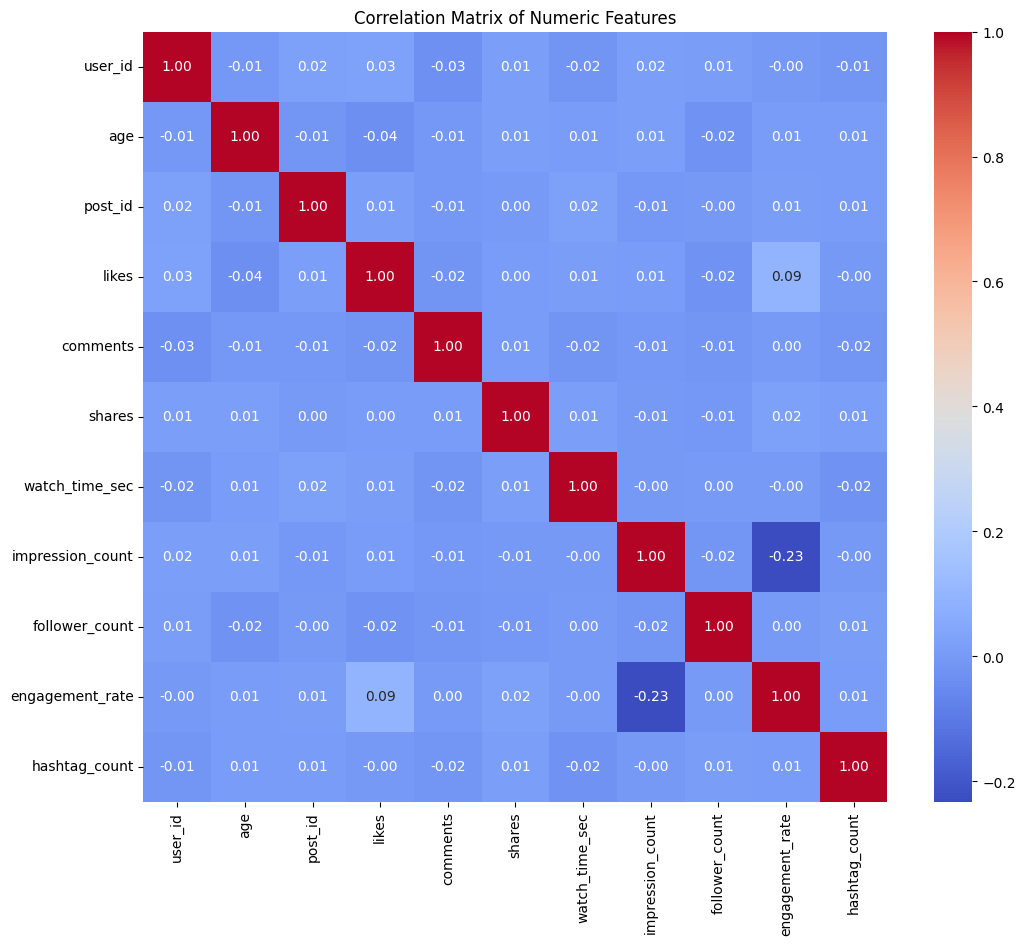

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=['int64', 'float64', 'Int64'])

print("Correlation Matrix for Numeric Fields:")
correlation_matrix = numeric_df.corr()
display(correlation_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### 6. Summarize Metrics using `groupby()`



In [ ]:
print("Average Likes by Post Type:")
display(df.groupby('post_type')['likes'].mean().sort_values(ascending=False))

print("\nAverage Impressions by Country:")
display(df.groupby('country')['impression_count'].mean().sort_values(ascending=False))

print("\nAverage Engagement Rate by Gender:")
display(df.groupby('gender')['engagement_rate'].mean().sort_values(ascending=False))

Average Likes by Post Type:


/tmp/ipykernel_1156/704181128.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('post_type')['likes'].mean().sort_values(ascending=False))


,likes
post_type,
video,10188.613878
image,10104.878107
text,10100.163855
reel,10037.819953



Average Impressions by Country:


/tmp/ipykernel_1156/704181128.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('country')['impression_count'].mean().sort_values(ascending=False))


,impression_count
country,
India,52462.386916
France,51727.673387
USA,51263.872255
UK,51119.393509
Japan,49616.135593
Brazil,49193.174603
UAE,48928.413519
Canada,48703.150097
Germany,48605.406122



Average Engagement Rate by Gender:


/tmp/ipykernel_1156/704181128.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('gender')['engagement_rate'].mean().sort_values(ascending=False))


,engagement_rate
gender,
Male,1.059003
Other,0.909324
Female,0.908307


# Data Wrangling

### 1. Combining DataFrames (Merge, Concat, Join)

Here's an example of how `pd.concat()` could be used to combine two small DataFrames:

In [ ]:
import pandas as pd

dummy_df1 = pd.DataFrame({
    'id': [1, 2, 3],
    'value1': ['A', 'B', 'C']
})
dummy_df2 = pd.DataFrame({
    'id': [4, 5, 6],
    'value1': ['D', 'E', 'F']
})

combined_df = pd.concat([dummy_df1, dummy_df2], ignore_index=True)
print("Example of pd.concat():")
display(combined_df)

Example of pd.concat():


,id,value1
0,1,A
1,2,B
2,3,C
3,4,D
4,5,E
5,6,F


### 2. Create New Fields

#### Creating `engagement_score` based on a weighted sum of likes, comments, and shares. The weights can be adjusted.

In [ ]:
df['engagement_score'] = (
    df['likes'] * 0.5 +
    df['comments'] * 0.3 +
    df['shares'] * 0.2
)

print("DataFrame head with new 'engagement_score' column:")
display(df[['likes', 'comments', 'shares', 'engagement_score']].head())

print("\nDescriptive statistics for 'engagement_score':")
display(df['engagement_score'].describe())

DataFrame head with new 'engagement_score' column:


,likes,comments,shares,engagement_score
0,7011,354,1157,3843.1
1,11750,2606,1807,7018.2
2,4862,344,955,2725.2
3,5350,1083,1049,3209.7
4,12682,2735,1300,7421.5



Descriptive statistics for 'engagement_score':


,engagement_score
count,5000.0
mean,5704.70026
std,2860.859932
min,82.8
25%,3293.25
50%,5699.05
75%,8155.35
max,11205.4


#### Creating Log-Transformed Metrics (Optional)

In [ ]:
import numpy as np

# Applying log transformation (log1p to handle potential zero values gracefully)
df['log_likes'] = np.log1p(df['likes'])
df['log_comments'] = np.log1p(df['comments'])
df['log_shares'] = np.log1p(df['shares'])

print("DataFrame head with new log-transformed columns:")
display(df[['likes', 'log_likes', 'comments', 'log_comments', 'shares', 'log_shares']].head())

print("\nDescriptive statistics for log-transformed metrics:")
display(df[['log_likes', 'log_comments', 'log_shares']].describe())

DataFrame head with new log-transformed columns:


,likes,log_likes,comments,log_comments,shares,log_shares
0,7011,8.855378,354,5.872118,1157,7.05445
1,11750,9.371694,2606,7.865955,1807,7.499977
2,4862,8.489411,344,5.843544,955,6.862758
3,5350,8.585039,1083,6.988413,1049,6.956545
4,12682,9.448018,2735,7.914252,1300,7.170888



Descriptive statistics for log-transformed metrics:


,log_likes,log_comments,log_shares
count,5000.0,5000.0,5000.0
mean,8.932957,7.018406,6.614072
std,0.959942,0.981985,0.97828
min,2.397895,0.0,0.0
25%,8.563313,6.675823,6.238325
50%,9.220984,7.311886,6.920672
75%,9.613135,7.712556,7.302496
max,9.903438,8.006368,7.600902


### 3. Perform `groupby()` Summaries



In [ ]:
print("\nTotal Watch Time and Average Impressions by Post Type:")
display(df.groupby('post_type', observed=False)[['watch_time_sec', 'impression_count']].sum().sort_values(by='watch_time_sec', ascending=False))

print("\nAverage Engagement Score by Country:")
display(df.groupby('country', observed=False)['engagement_score'].mean().sort_values(ascending=False))

print("Average Engagement Metrics by Sentiment:")
display(df.groupby('sentiment', observed=False)[['likes', 'comments', 'shares', 'engagement_score']].mean().sort_values(by='engagement_score', ascending=False))



Total Watch Time and Average Impressions by Post Type:


,watch_time_sec,impression_count
post_type,,
reel,5306138,64743514
text,4993537,62234087
video,4932675,61080968
image,4840166,62010095



Average Engagement Score by Country:


,engagement_score
country,
France,5840.415726
Australia,5798.75071
UAE,5773.93002
Germany,5719.464694
USA,5697.602395
Japan,5695.437076
Canada,5694.762963
India,5636.784299
UK,5603.88073


Average Engagement Metrics by Sentiment:


,likes,comments,shares,engagement_score
sentiment,,,,
negative,10208.1125,1516.094792,1007.307292,5760.346146
positive,10180.077199,1480.650617,1005.086749,5735.251134
neutral,9923.208906,1528.40406,996.56516,5619.438703


## Statistical Analysis

In [ ]:
numerical_cols_for_stats = ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']

print("Descriptive Statistics for Key Numerical Columns:\n")

for col in numerical_cols_for_stats:
    print(f"--- Statistics for '{col}' ---")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")

    mode_val = df[col].mode()
    if len(mode_val) == 1:
        print(f"Mode: {mode_val.iloc[0]:.2f}")
    else:
        print(f"Mode: {mode_val.tolist()}")
    print(f"Standard Deviation: {df[col].std():.2f}")
    print(f"Variance: {df[col].var():.2f}")
    print(f"25th Percentile: {df[col].quantile(0.25):.2f}")
    print(f"75th Percentile: {df[col].quantile(0.75):.2f}")
    print(f"Skewness: {df[col].skew():.2f}")
    print(f"Kurtosis: {df[col].kurtosis():.2f}")
    print("\n")


Descriptive Statistics for Key Numerical Columns:

--- Statistics for 'likes' ---
Mean: 10107.01
Median: 10106.00
Mode: 10106.00
Standard Deviation: 5702.29
Variance: 32516145.62
25th Percentile: 5235.00
75th Percentile: 14959.00
Skewness: -0.01
Kurtosis: -1.15


--- Statistics for 'comments' ---
Mean: 1502.04
Median: 1497.00
Mode: 1497.00
Standard Deviation: 856.39
Variance: 733409.50
25th Percentile: 792.00
75th Percentile: 2235.25
Skewness: 0.00
Kurtosis: -1.14


--- Statistics for 'shares' ---
Mean: 1002.91
Median: 1012.00
Mode: 1012.00
Standard Deviation: 570.86
Variance: 325875.66
25th Percentile: 511.00
75th Percentile: 1483.00
Skewness: -0.01
Kurtosis: -1.15


--- Statistics for 'watch_time_sec' ---
Mean: 4014.50
Median: 4034.50
Mode: [916, 2145, 4360, 7003, 7688]
Standard Deviation: 2308.10
Variance: 5327309.26
25th Percentile: 2017.75
75th Percentile: 6020.25
Skewness: -0.02
Kurtosis: -1.20


--- Statistics for 'engagement_rate' ---
Mean: 0.96
Median: 0.25
Mode: [0.006362909,

## Data Visualization

### 1. Scatter Plot: Likes vs. Impressions

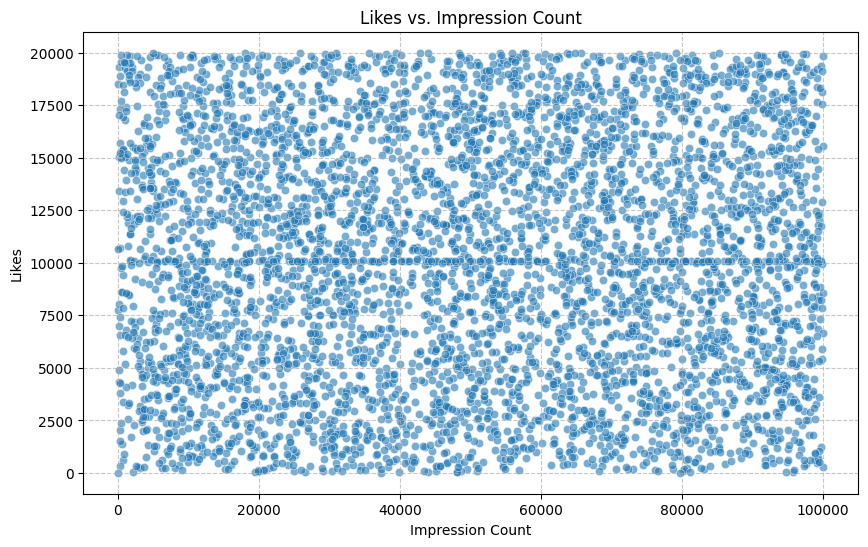

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='impression_count', y='likes', data=df, alpha=0.6)
plt.title('Likes vs. Impression Count')
plt.xlabel('Impression Count')
plt.ylabel('Likes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

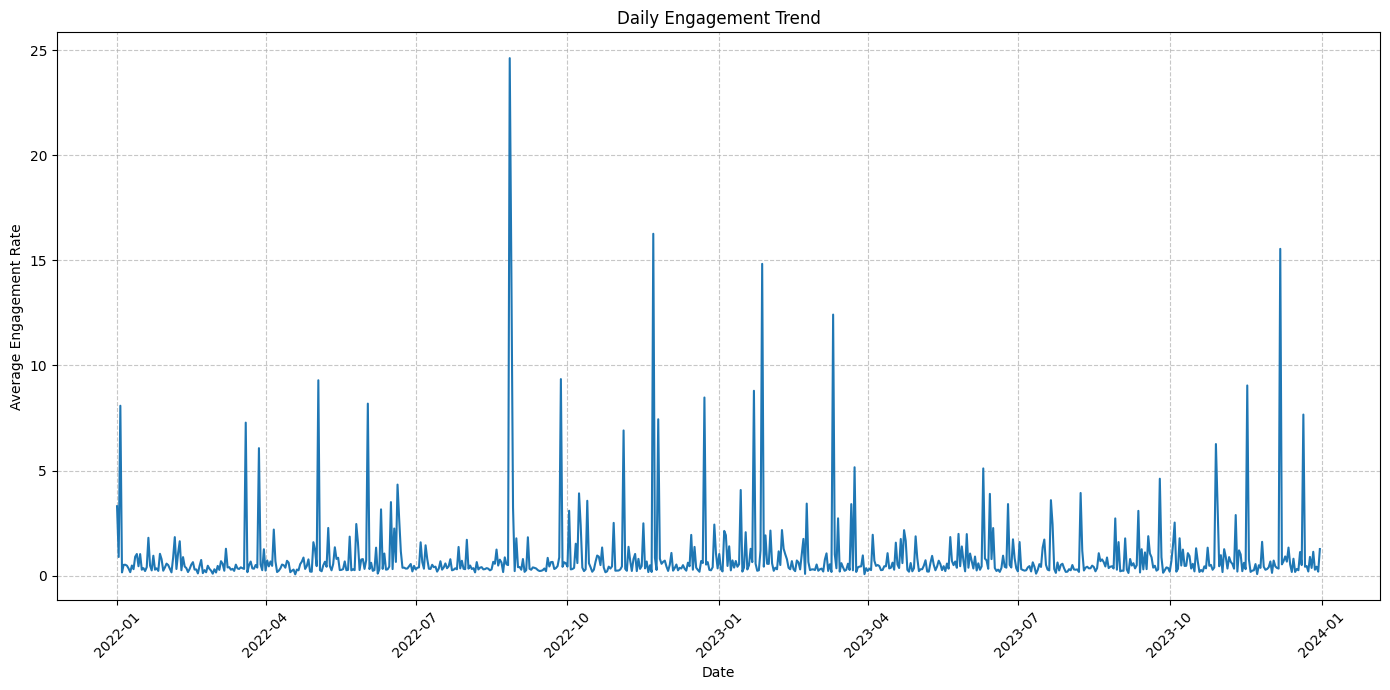

In [ ]:
df['posted_date'] = df['posted_at'].dt.date
daily_engagement = df.groupby('posted_date')['engagement_rate'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='posted_date', y='engagement_rate', data=daily_engagement)
plt.title('Daily Engagement Trend')
plt.xlabel('Date')
plt.ylabel('Average Engagement Rate')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1156/2289962748.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='post_category', data=df, order=df['post_category'].value_counts().index, palette='viridis')


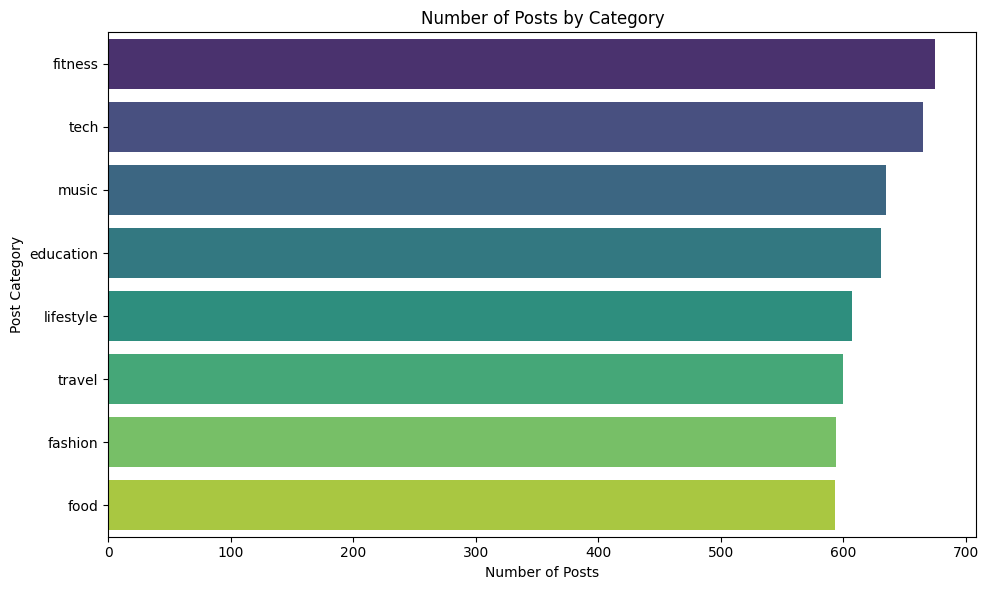

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(y='post_category', data=df, order=df['post_category'].value_counts().index, palette='viridis')
plt.title('Number of Posts by Category')
plt.xlabel('Number of Posts')
plt.ylabel('Post Category')
plt.tight_layout()
plt.show()

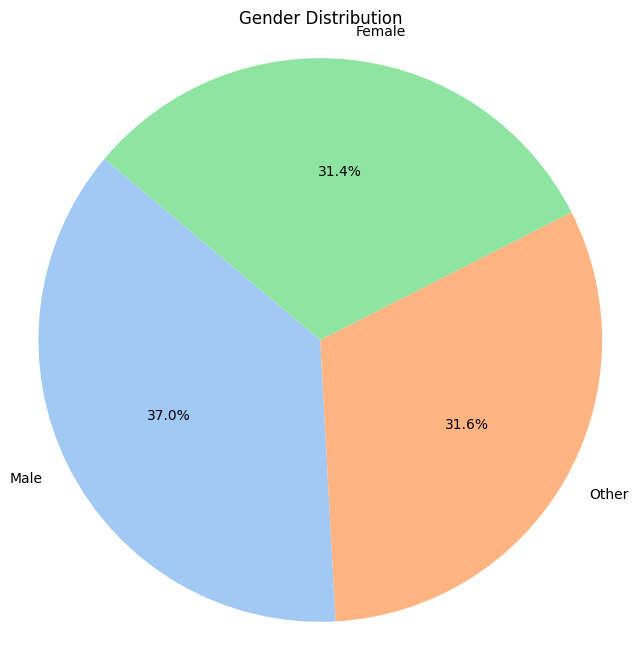

In [ ]:
gender_distribution = df['gender'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(gender_distribution, labels=gender_distribution.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Gender Distribution')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

/tmp/ipykernel_1156/4082197924.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['age'], bins=20, kde=True, palette='viridis')


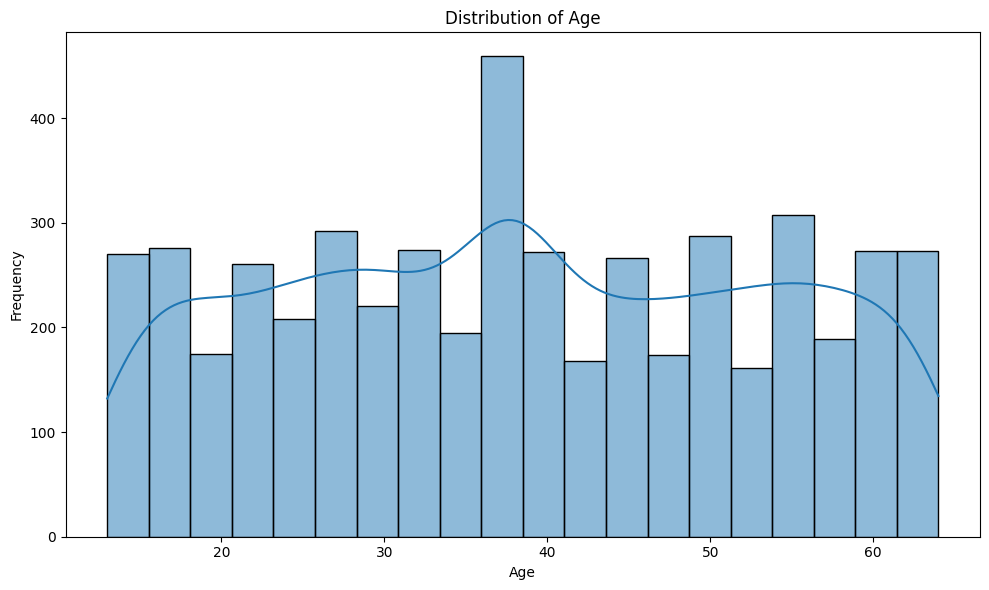

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True, palette='viridis')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1156/517608006.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df['engagement_rate'], palette='viridis')


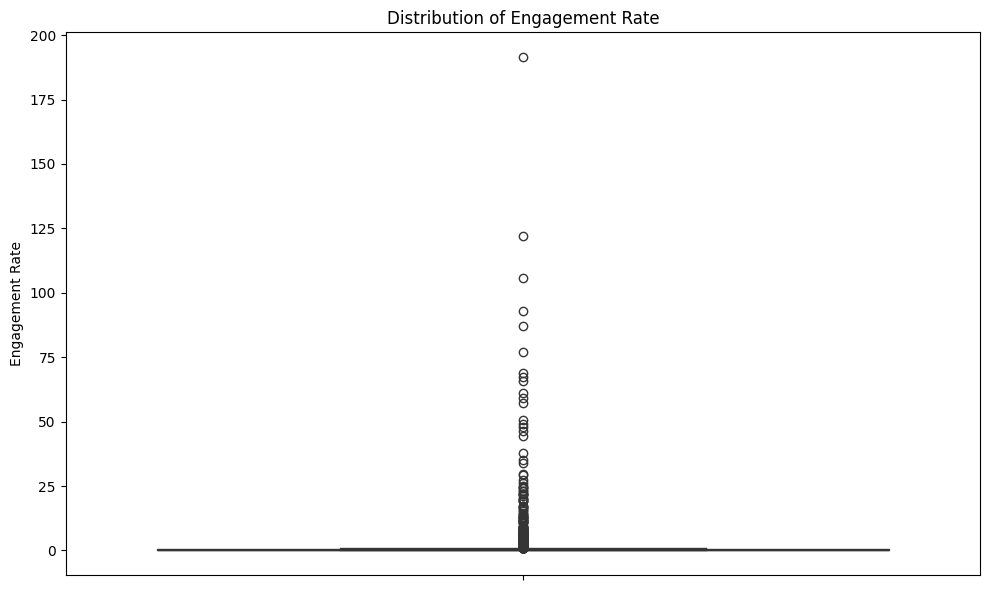

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['engagement_rate'], palette='viridis')
plt.title('Distribution of Engagement Rate')
plt.ylabel('Engagement Rate')
plt.tight_layout()
plt.show()

### Count Plot: Post Type Distribution

/tmp/ipykernel_1156/1476161810.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='post_type', data=df, order=df['post_type'].value_counts().index, palette='crest')


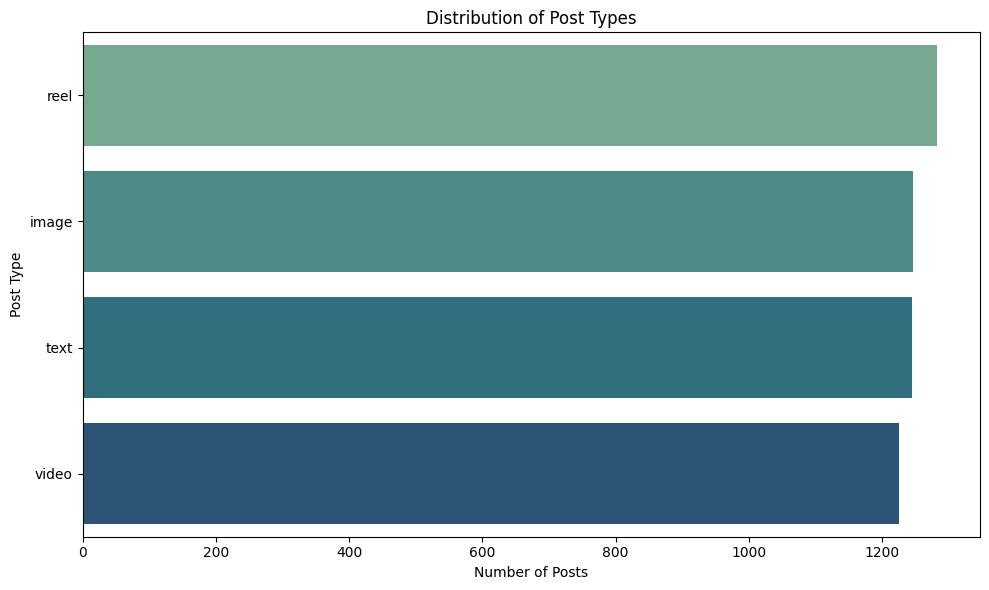

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(y='post_type', data=df, order=df['post_type'].value_counts().index, palette='crest')
plt.title('Distribution of Post Types')
plt.xlabel('Number of Posts')
plt.ylabel('Post Type')
plt.tight_layout()
plt.show()

### Violin Plot: Follower Count vs. Sentiment

/tmp/ipykernel_1156/1702798222.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='sentiment', y='follower_count', data=df, palette='magma')


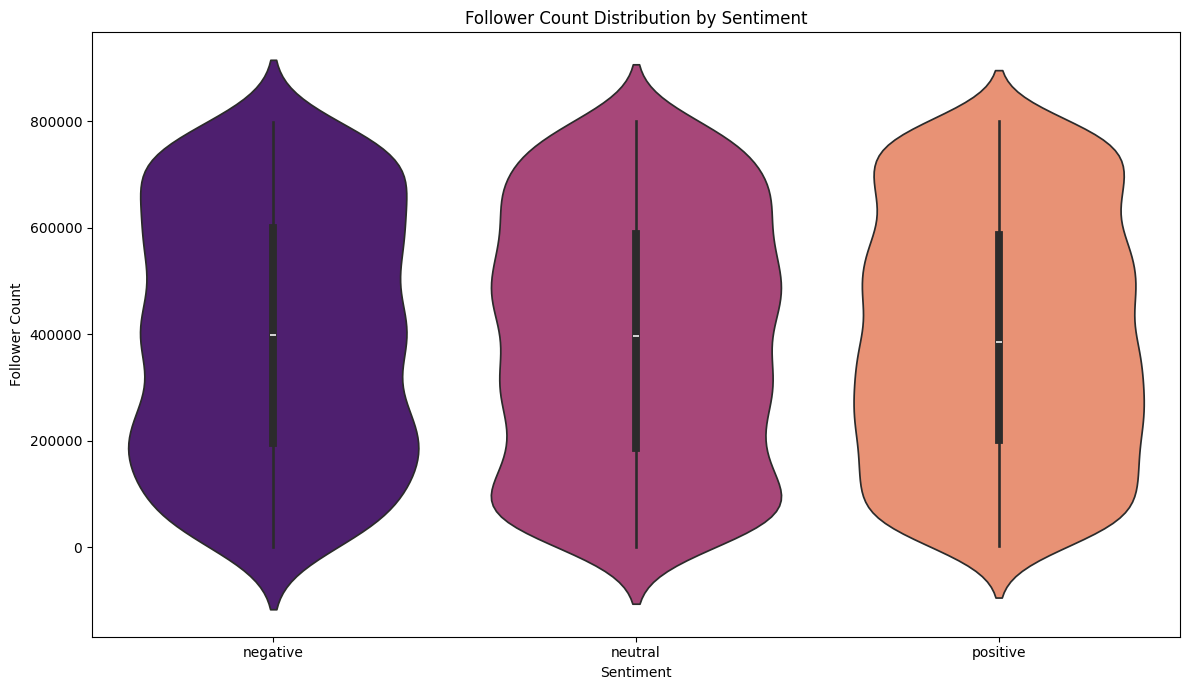

In [ ]:
plt.figure(figsize=(12, 7))
sns.violinplot(x='sentiment', y='follower_count', data=df, palette='magma')
plt.title('Follower Count Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Follower Count')
plt.tight_layout()
plt.show()

### Pair Plot: Numeric Features

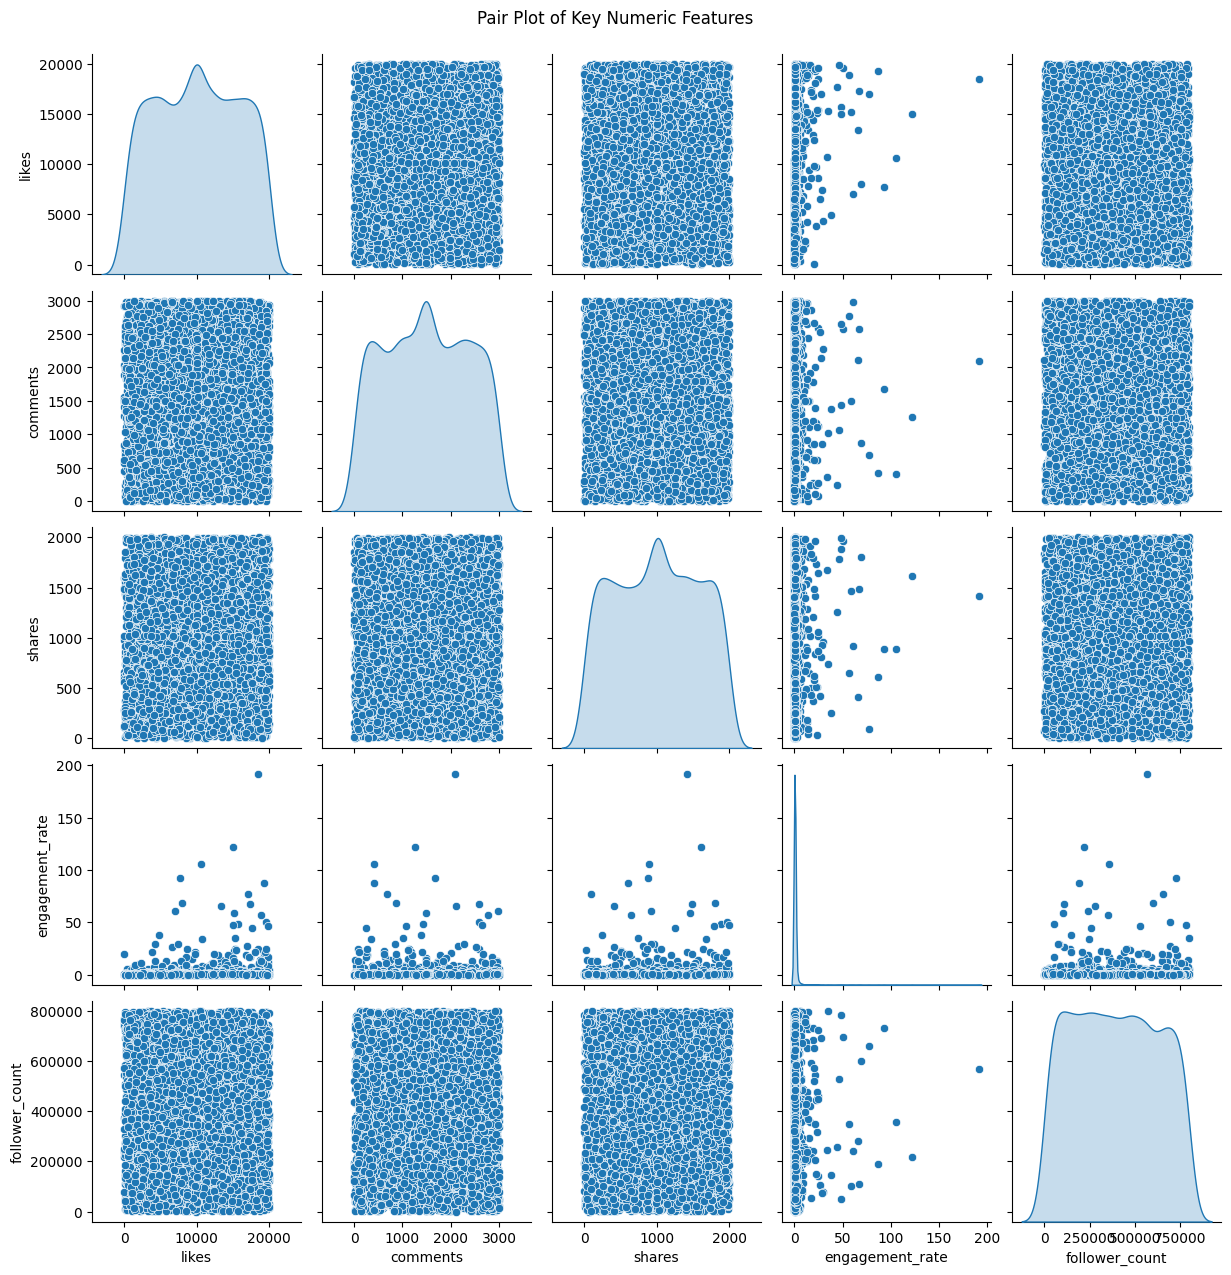

In [77]:
numeric_features_for_pairplot = ['likes', 'comments', 'shares', 'engagement_rate', 'follower_count']

sns.pairplot(df[numeric_features_for_pairplot], diag_kind='kde')
plt.suptitle('Pair Plot of Key Numeric Features', y=1.02) # Adjusted suptitle to prevent overlap
plt.show()

### Swarm Plot: Engagement Rate vs. Device Type

/tmp/ipykernel_1156/2395478806.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='device_type', y='engagement_rate', data=df, palette='viridis', size=3)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 87.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 86.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 87.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/d

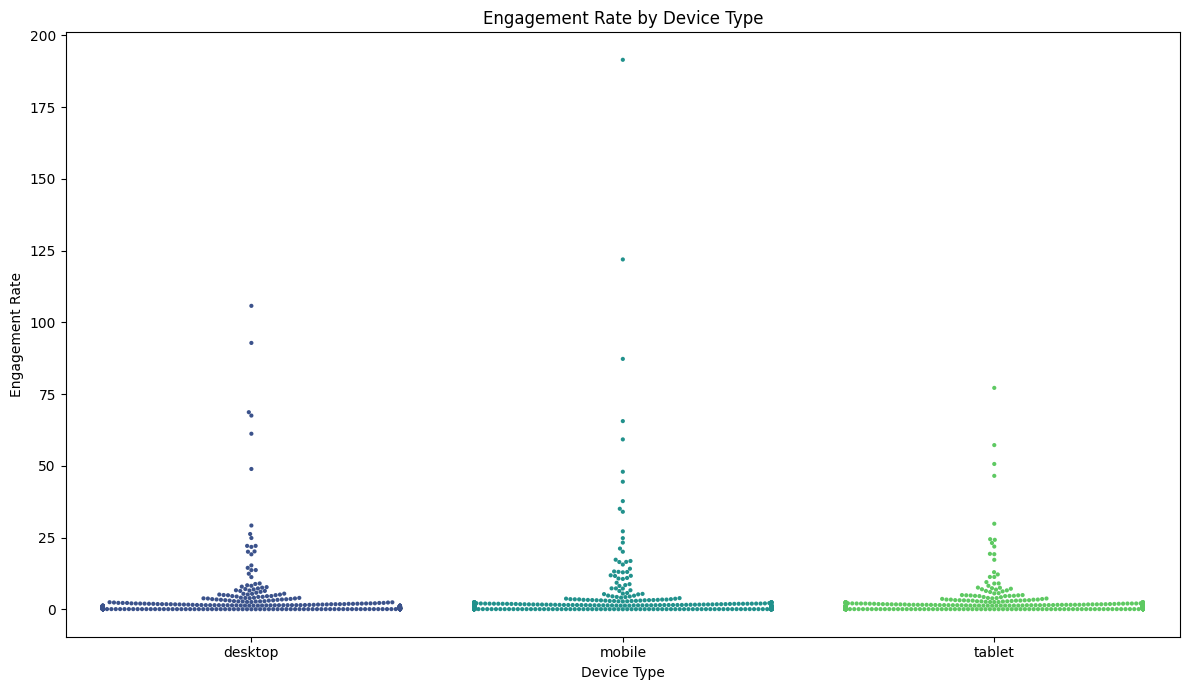

In [ ]:
plt.figure(figsize=(12, 7))
sns.swarmplot(x='device_type', y='engagement_rate', data=df, palette='viridis', size=3)
plt.title('Engagement Rate by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Engagement Rate')
plt.tight_layout()
plt.show()

In [72]:
import plotly.express as px

### Interactive Bubble Chart: Likes, Comments, Shares (Plotly)

In [75]:
fig = px.scatter(df, x='likes', y='comments', size='shares', color='post_category',
                 hover_name='post_id', log_x=True, size_max=60,
                 title='Interactive Bubble Chart: Likes vs. Comments (Size by Shares, Color by Post Category)')
fig.show()

# Thank you